In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import importlib
import sys
sys.path.append("..")
import src.assay_calibration.fit_utils.multivariate.density_utils
importlib.reload(src.assay_calibration.fit_utils.multivariate.density_utils)
from src.assay_calibration.fit_utils.multivariate.density_utils import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x, a,loc,scale = 1,-1,1,5
print(multivariate_skewnorm.pdf(x, a,loc, scale**2))
print(sps.skewnorm.pdf(x, a, loc, scale))

0.07978845608028656
0.07978845608028654


In [4]:
# msn = multivariate_skewnorm(a=[0,0],loc=[0,0], cov=[[1,0.9],[0.9,1]])
# # grid from -5 to 5
# x = np.linspace(-5, 5, 70)
# y = np.linspace(-5, 5, 70)

# X, Y = np.meshgrid(x, y)

# # evaluate pdf on the grid
# Z = np.zeros_like(X)

# for i in range(X.shape[0]):
#     for j in range(X.shape[1]):
#         Z[i, j] = msn.pdf([X[i, j], Y[i, j]])

# # heatmap
# plt.imshow(
#     Z,
#     extent=[-5, 5, -5, 5],
#     origin="lower",
#     aspect="auto"
# )

# plt.colorbar(label="pdf value")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.title("Heatmap of msn.pdf([x, y])")
# plt.show()

In [5]:
# msn = multivariate_skewnorm([0.5],[-3],[[30]])

# # 1D grid from -5 to 5
# x = np.linspace(-5, 15, 500)
# if x.ndim == 1:
#     x = x.reshape(-1, 1)

# # evaluate pdf
# y = msn.pdf(x)

# # plot
# plt.plot(x, y)
# plt.xlabel("x")
# plt.ylabel("pdf")
# plt.title("PDF of 1D data")
# plt.show()

In [6]:
# !pip install fire

In [7]:
from src.assay_calibration.data_utils.dataset import (
    PillarProjectDataframe,
    Scoreset,
    BasicScoreset,
    MultiScoreset
)
import pandas as pd

In [8]:
df = pd.read_csv("/Users/rossaroni/Downloads/integrated_variant_effect_dataset.tsv.gz", sep='\t')

/var/folders/5h/tvwc29x95xv2dpt92wyp7xf80000gn/T/ipykernel_16062/1825769336.py:1: DtypeWarning: Columns (0: Chrom, 1: auth_transcript_id, 2: auth_reported_score, 3: auth_reported_rep_score, 4: auth_reported_func_class, 5: MaveDB Score Set URN, 6: Phenotype Measured ontology term, 7: Molecular or Biological Process Investigated (GO term), 8: Interval 1 name, 9: Interval 1 range, 10: Interval 1 MaveDB class, 11: Interval 2 name, 12: Interval 2 range, 13: Interval 2 MaveDB class, 14: Interval 3 name, 15: Interval 3 range, 16: Interval 3 MaveDB class, 17: Interval 4 name, 18: Interval 4 range, 19: Interval 4 MaveDB class, 20: Interval 5 name, 21: Interval 5 range, 22: Interval 5 MaveDB class, 23: Flag, 24: AM_class, 25: MP2_train, 26: REVEL_train, 27: clinvar_sig_2018, 28: clinvar_star_2018, 29: clinvar_date_last_reviewed_2018, 30: Allele Registry Id_ClinGen_repo, 31: Disease_ClinGen_repo, 32: Mondo Id_ClinGen_repo, 33: Mode of Inheritance_ClinGen_repo, 34: Assertion_ClinGen_repo, 35: Appl

In [9]:

scoreset_assay1 = Scoreset(df[df.Dataset == "GCK_Gersing_2023_complementation"])
scoreset_assay2 = Scoreset(df[df.Dataset == "GCK_Gersing_2024_abundance"])

In [10]:
import importlib
import src.assay_calibration.data_utils.dataset
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import MultiScoreset, Scoreset, BasicScoreset


# Build multi-assay scoreset
ms = MultiScoreset([scoreset_assay1, scoreset_assay2])
print(ms)  # shows missing %, sample counts

MultiScoreset: GCK_Gersing_2023_complementation + GCK_Gersing_2024_abundance
  1054 variants, 2 assays
  Dim 0 (GCK_Gersing_2023_complementation): 954/1054 observed
  Dim 1 (GCK_Gersing_2024_abundance): 965/1054 observed
  Overall: 9.0% missing entries
  Pathogenic/Likely Pathogenic: 335 variants
  Benign/Likely Benign: 10 variants
  population: 481 variants
  Synonymous: 340 variants



In [34]:
import importlib
import src.assay_calibration.fit_utils.fit
import src.assay_calibration.fit_utils.multivariate.initializations
importlib.reload(src.assay_calibration.fit_utils.fit)
importlib.reload(src.assay_calibration.fit_utils.multivariate.initializations)
from src.assay_calibration.fit_utils.fit import Fit

import traceback
try:
    models, best_idx, best_val_ll = Fit(ms).run(
        component_range=[3],
        num_fits=1,
        check_monotonic=False,
        bootstrap=False,
        raise_on_error=True,
        core_limit=1,
        verbose=True,
        max_em_steps=1000
    )
except Exception as e:
    traceback.print_exc()

sample counts: [335  10 481 340]
sample counts (after one-hot): [291   7 416 340]
[INIT] mv=True, method=kmeans_mv, obs shape=(1054, 2), NaN count=189, xlims=((-1.01770374643558, 4.66796791662614), (-0.571413688659232, 1.55466243664064))


EM Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

In [21]:
models[best_idx]

{'component_params': [(array([0.09205454, 0.27696003]),
   array([ 0.01053749, -0.02848202]),
   array([[ 0.13139215, -0.00354917],
          [-0.00354917,  0.12923178]])),
  (array([0.58369214, 0.79928747]),
   array([0.04829208, 0.00161508]),
   array([[ 0.32387506, -0.05959597],
          [-0.05959597,  0.04047049]])),
  (array([1.07626802, 0.9973639 ]),
   array([ 0.03525836, -0.01693137]),
   array([[0.30480568, 0.00237774],
          [0.00237774, 0.02681463]]))],
 'weights': array([[6.47665035e-001, 2.92689631e-001, 5.96453337e-002],
        [0.00000000e+000, 3.09259240e-179, 1.00000000e+000],
        [1.28795404e-001, 4.68292526e-001, 4.02912070e-001],
        [6.32992353e-003, 5.40961675e-005, 9.93615980e-001]]),
 'likelihoods': array([-0.9377094 , -0.87113663, -0.84753804, -0.8342955 , -0.82249579,
        -0.81399163, -0.81057933, -0.80921491, -0.80849938, -0.80799017,
        -0.80751455, -0.80713198, -0.80686829, -0.80667197, -0.80653677,
        -0.80644108, -0.80627098, -

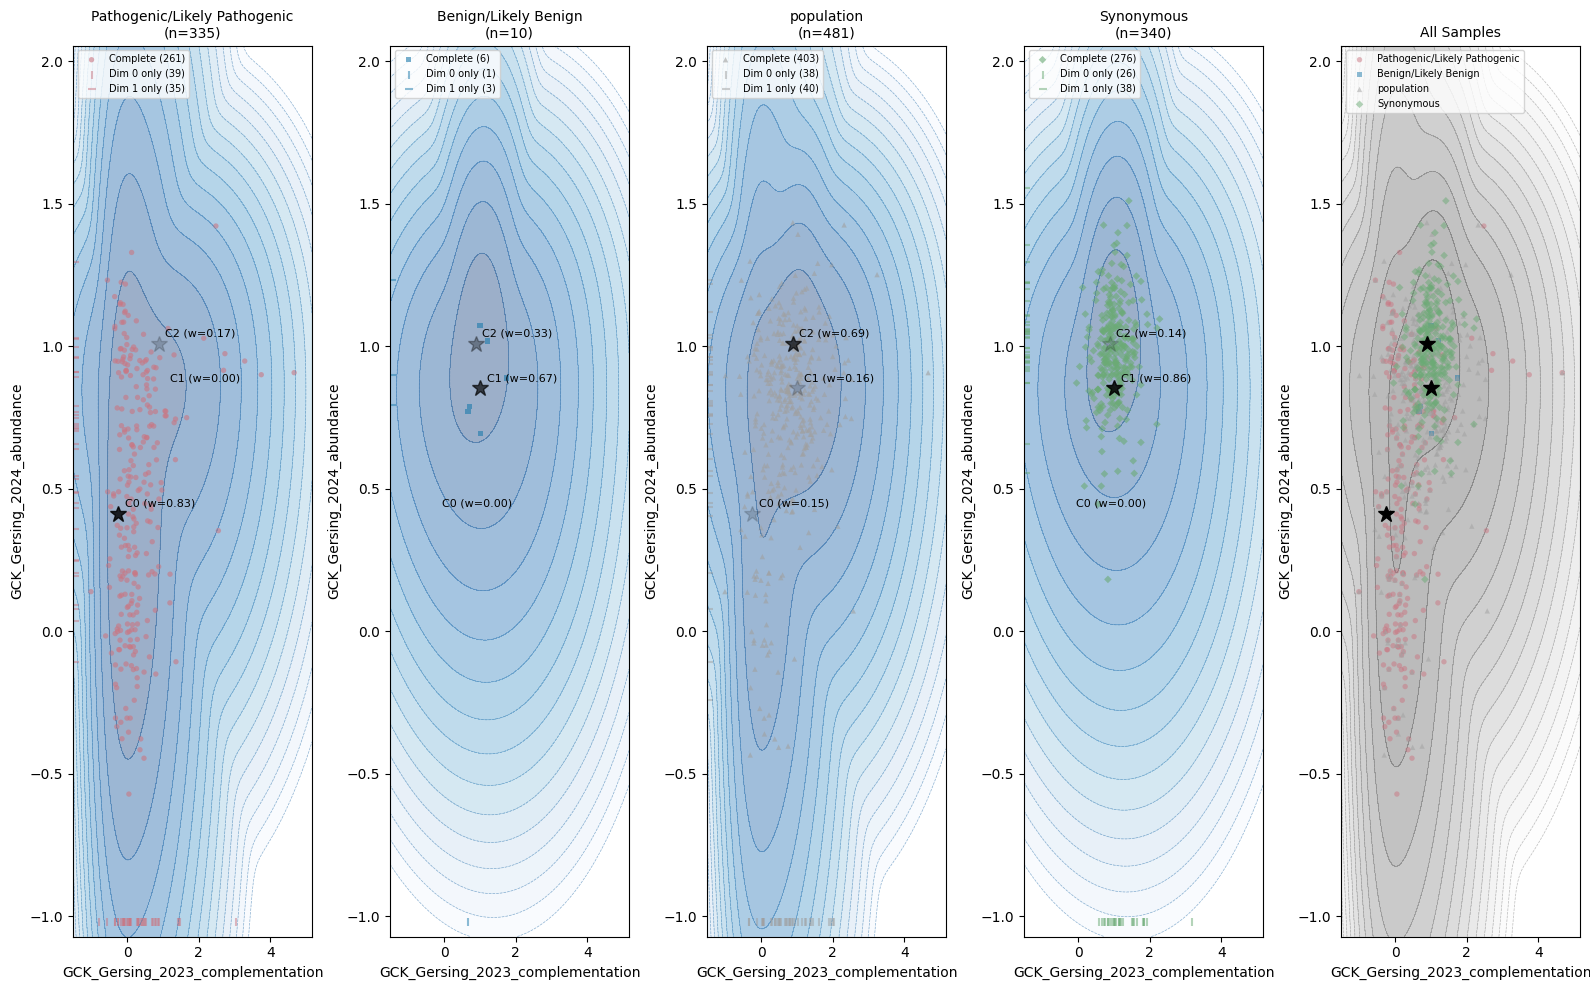

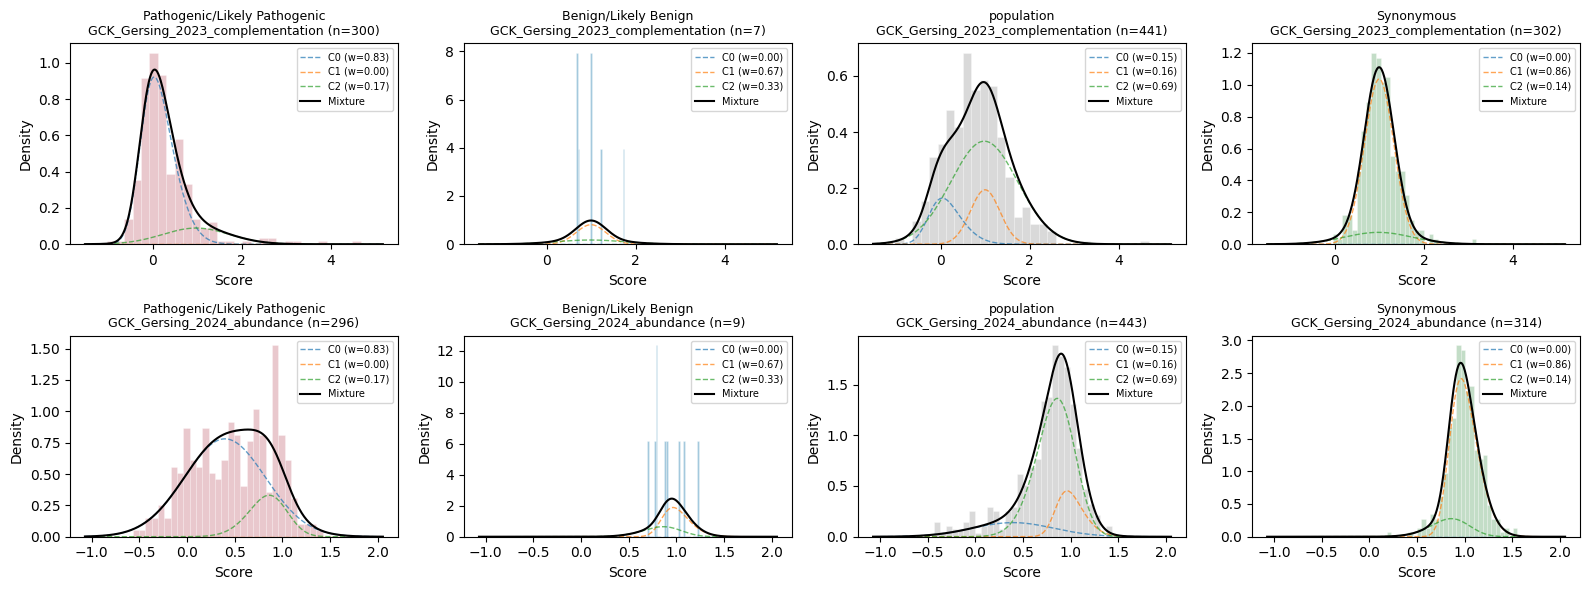


FIT SUMMARY

Component 0:
  mu    = [-0.24788773  0.41180197]
  Delta = [ 0.48714694 -0.0181829 ]
  Omega = 
    [ 0.29239943 -0.0034483 ]
    [-0.0034483   0.18112914]
  Gamma eigenvalues = [0.05485495 0.18103086]

Component 1:
  mu    = [1.00279939 0.85178041]
  Delta = [-0.00856197  0.19520578]
  Omega = 
    [0.10968457 0.00511522]
    [0.00511522 0.04637407]
  Gamma eigenvalues = [0.00781632 0.11006372]

Component 2:
  mu    = [0.87395889 1.0079634 ]
  Delta = [ 0.13082948 -0.22164448]
  Omega = 
    [ 0.57383834 -0.01815836]
    [-0.01815836  0.0737564 ]
  Gamma eigenvalues = [0.02440941 0.55694271]

Weights:
  Pathogenic/Likely Pathogenic: [8.32250752e-001 4.14240675e-184 1.67749248e-001]
  Benign/Likely Benign: [0.         0.67146761 0.32853239]
  population: [0.14825397 0.16104805 0.69069798]
  Synonymous: [4.27584320e-66 8.60002423e-01 1.39997577e-01]

Final log-likelihood: -0.736253
Iterations: 1239


In [35]:
import visualize_fit
importlib.reload(visualize_fit)
from visualize_fit import plot_mv_fit  # or just paste the function in a cell

fit_result = models[best_idx]
plot_mv_fit(ms, fit_result)

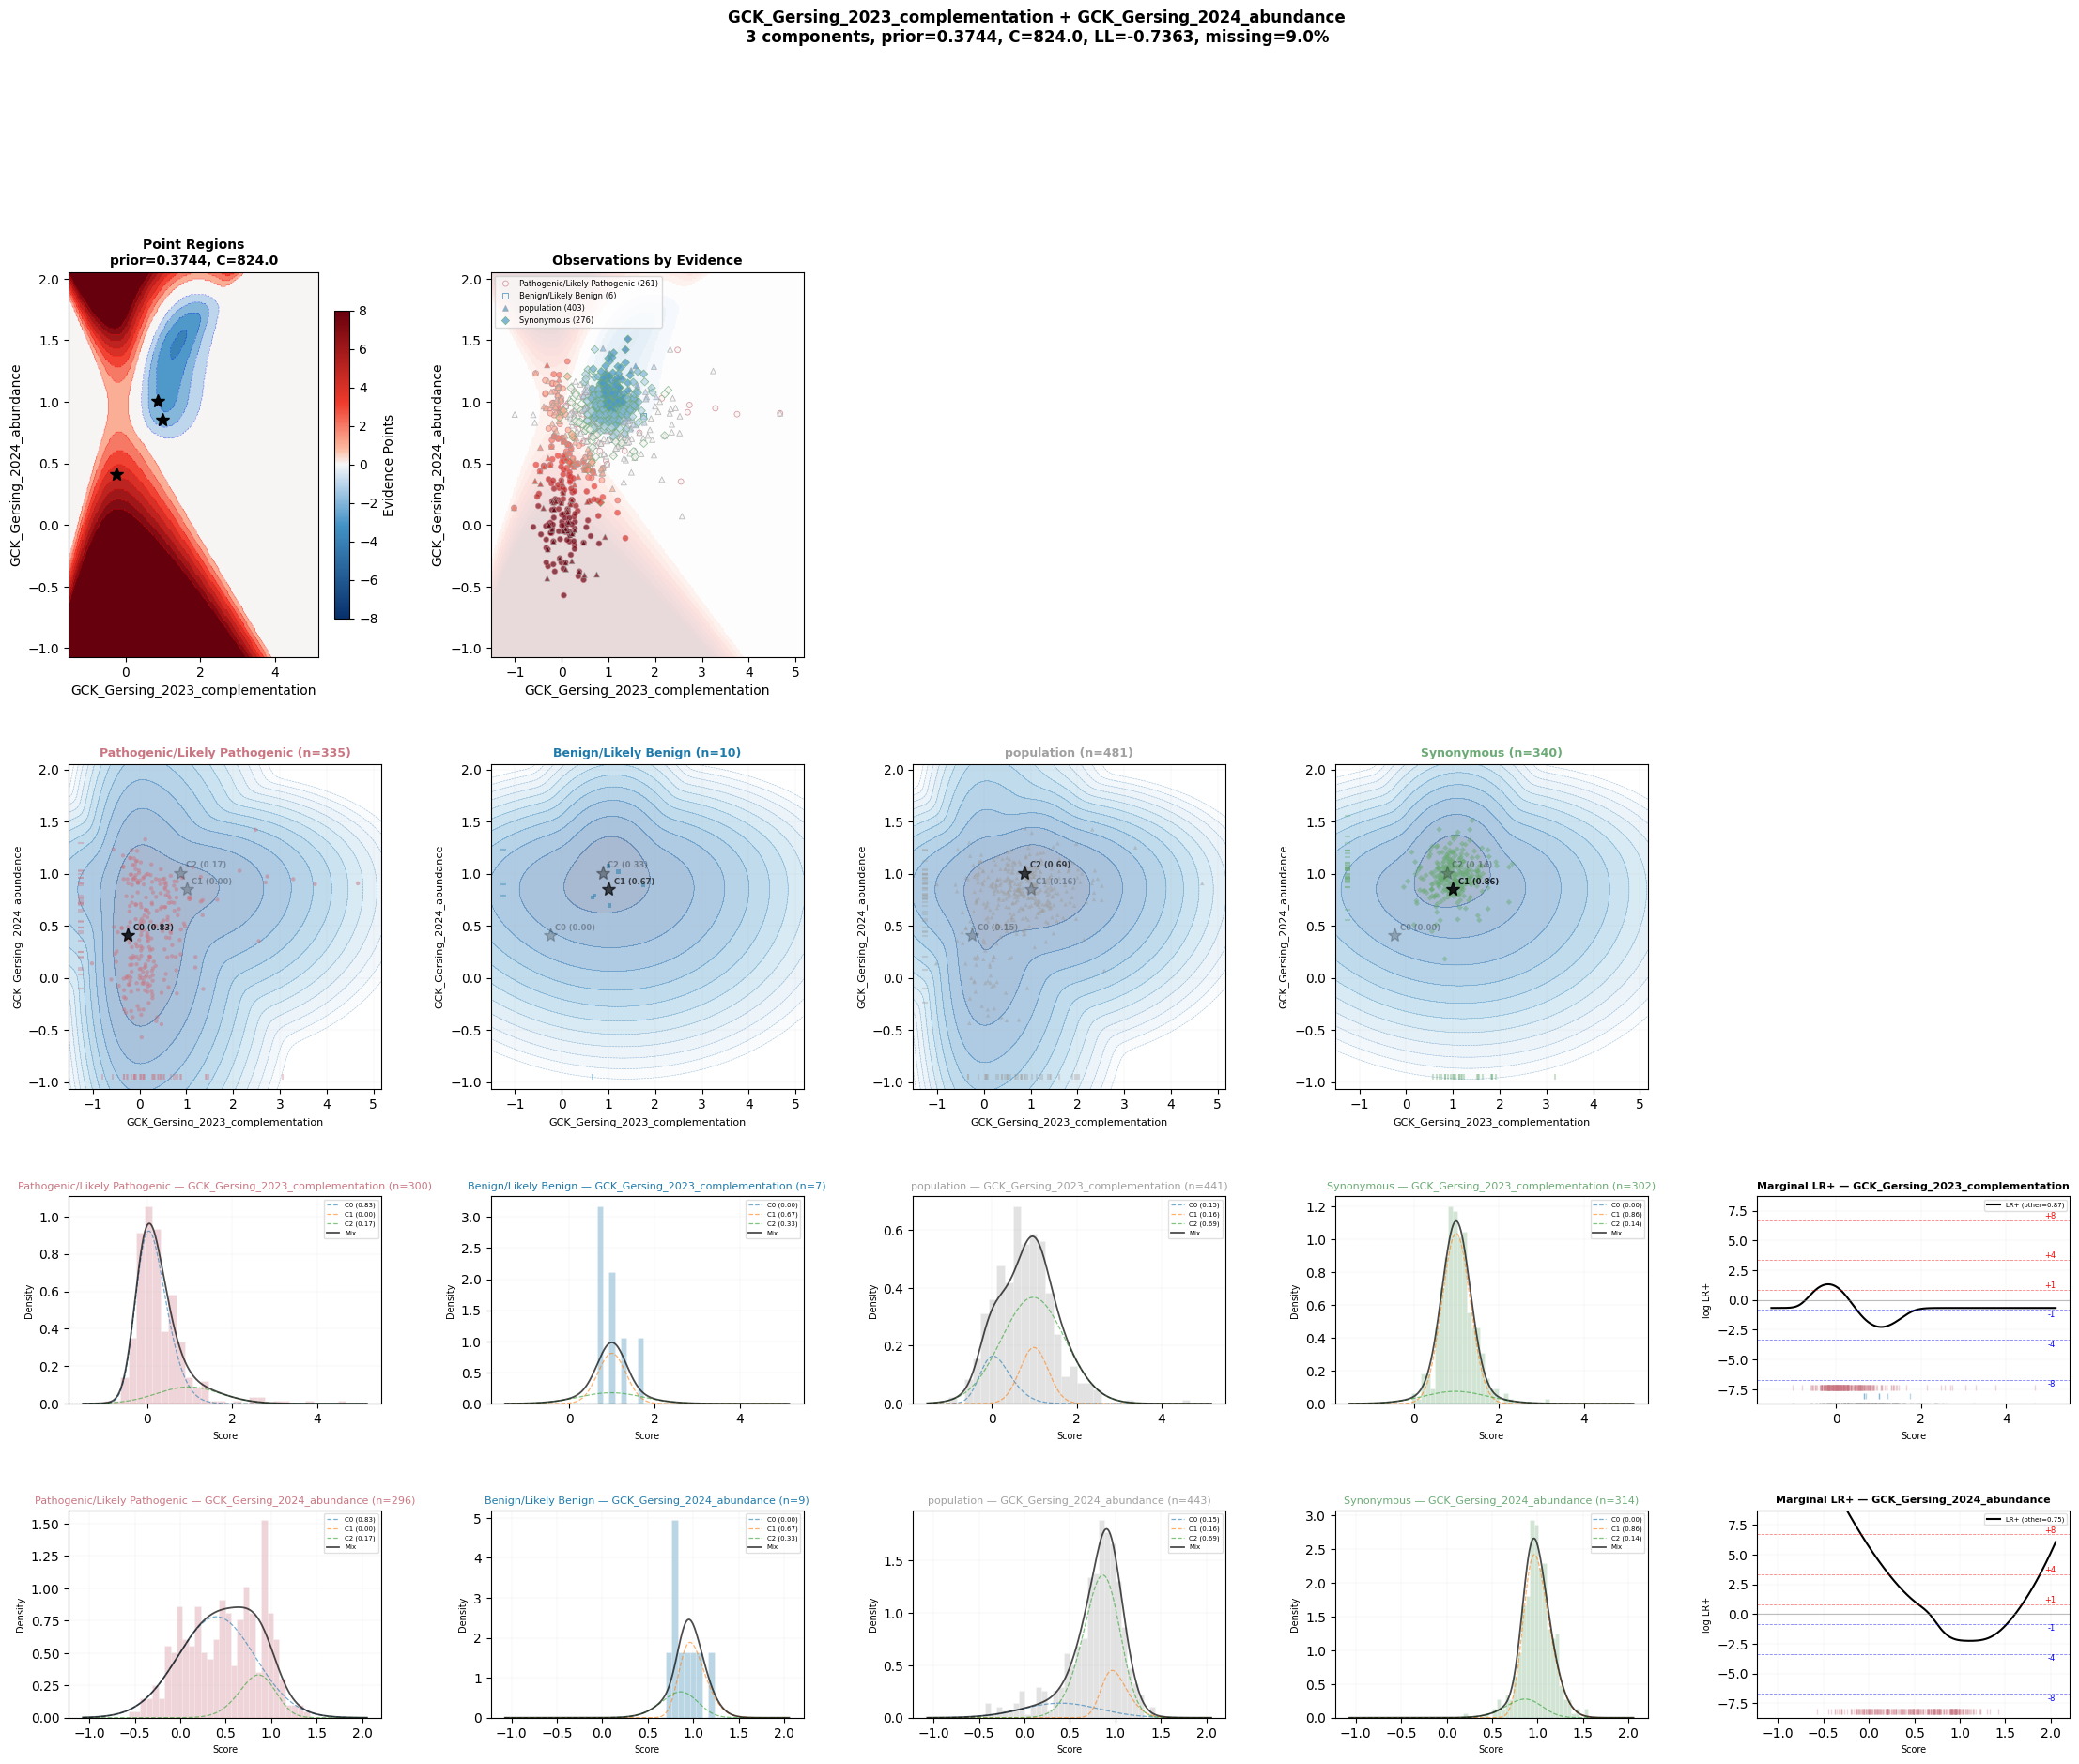

Prior: 0.3744
C: 824.0
Point distribution: (array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.]), array([  2, 138, 167, 123, 166,  78,  42,  22,  17,  17,   9,  15,  69]))


In [36]:
importlib.reload(visualize_fit)
from visualize_fit import plot_mv_calibration, compute_mv_prior

fit_result = models[best_idx]

# Auto-compute prior or supply your own
fig, info = plot_mv_calibration(
    ms, fit_result,
    prior=None,              # auto-compute via EM
    point_values=[1,2,3,4,5,6,7,8],
    pathogenic_idx=0,
    benign_idx=1,
    gnomad_idx=2,
    synonymous_idx=3,
    benign_method='benign',  # or 'synonymous' or 'avg'
    title=ms.scoreset_name,
)
plt.show()

# Access computed quantities
print(f"Prior: {info['prior']:.4f}")
print(f"C: {info['C']:.1f}")
print(f"Point distribution: {np.unique(info['obs_points'][~np.isnan(info['obs_points'])], return_counts=True)}")


ModuleNotFoundError: No module named 'tqdm'

In [ ]:
dataframe_f = f"/data/ross/assay_calibration/dataframe/integrated_variant_effect_dataset.tsv.gz"
df = pd.read_csv(dataframe_f, sep='\t')

/tmp/ipykernel_227062/2945358940.py:2: DtypeWarning: Columns (5,12,13,23,24,25,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,52,55,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_f, sep='\t')


In [ ]:
scoreset_1 = Scoreset(df[df.Dataset == "GCK_Gersing_2023_complementation"])
scoreset_2 = Scoreset(df[df.Dataset == "GCK_Gersing_2024_abundance"])

In [ ]:
scoreset_1, scoreset_2

(GCK_Gersing_2023_complementation: 3496 total variants
 	Pathogenic/Likely Pathogenic: 300 variants
 	Benign/Likely Benign: 7 variants
 	population: 441 variants
 	Synonymous: 302 variants,
 GCK_Gersing_2024_abundance: 3490 total variants
 	Pathogenic/Likely Pathogenic: 296 variants
 	Benign/Likely Benign: 9 variants
 	population: 443 variants
 	Synonymous: 314 variants)

In [ ]:
scoreset_1

GCK_Gersing_2023_complementation: 3496 total variants
	Pathogenic/Likely Pathogenic: 300 variants
	Benign/Likely Benign: 7 variants
	population: 441 variants
	Synonymous: 302 variants

In [ ]:
import importlib
import src.assay_calibration.data_utils.dataset
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import MultiScoreset, Scoreset, BasicScoreset

multiscoreset = MultiScoreset([scoreset_1, scoreset_2])

IndexError: Boolean index has wrong length: 2935 instead of 3496

In [ ]:
multiscoreset

MultiScoreset: 3773 variants × 2 datasets
	GCK_Gersing_2023_complementation: 2935 variants present
	GCK_Gersing_2024_abundance: 2927 variants present

In [ ]:
multiscoreset.scores

AttributeError: 'MultiScoreset' object has no attribute 'scores'

In [ ]:

for dataset_f in glob.glob("/data/ross/assay_calibration/scoresets/*.json"):
    
    dataset_name = dataset_f.split('/')[-1][:-5]

    for component_range in ("2-component","3-component"):
        for monotonicity_contraint in ("no constraint","constraint"):
            # for init_strategy in ("kmeans","random"):
            init_strategy = "kmeans"
            
            fits, ds = test_fit(dataset_f, component_range=[3] if component_range[0] == "3" else [2], 
                                check_monotonic=False if monotonicity_contraint[0] == "n" else True, 
                                init_strategy=init_strategy)
            
            fit_results = sorted(fits, key=lambda res: res['likelihoods'][-1], reverse=True)
            best_fit = fit_results[0]
            scores = ds.scores
            sample_assignments = ds.sample_assignments
            
            score_range = np.linspace(scores.min(), scores.max(), 1000)
            estimatedDensities = np.array([density_utils.joint_densities(score_range[...,None],
                                                                         best_fit['component_params'],
                                                                         sample_weights).squeeze() for sample_weights in best_fit['weights']])
            
            fig,ax = plt.subplots(3,1, figsize=(12,12))
            for i in range(3):
                ax[i].plot(score_range, estimatedDensities[i].sum(0), label='Estimated', color='C1', linestyle='--')
                ax[i].hist(scores[sample_assignments[:,i]], density=True, alpha=0.3, color='gray', label='Data histogram')
                ax[i].set_title(f'Sample {i+1}')
                ax[i].legend()

In [ ]:
def test_fit(ds, component_range, check_monotonic, init_strategy):
    # Load directly from JSON
    fit = Fit(ds)
    fits = fit.run(
                core_limit=20,
                num_fits=20,
                verbose_level=20,
                component_range=component_range,
                bootstrap=False,
                verbose=False,
                max_em_iters=10000,
                check_convergence=False,
                check_monotonic=check_monotonic,
                init_strategy=init_strategy,
                score_min=ds.scores.min() - 1,
                score_max=ds.scores.max() + 1,
                # kmean_init="k-means++"
            )
    
    return fits, ds


In [ ]:
#### import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# Create output directory if it doesn't exist
output_dir = "/data/ross/assay_calibration/test_experimental_plots_v3"
os.makedirs(output_dir, exist_ok=True)

# Suppress matplotlib debug messages
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

for dataset_f in glob.glob("/data/ross/assay_calibration/scoresets/*.json"):
    
    dataset_name = dataset_f.split('/')[-1][:-5]
    print(f"Processing {dataset_name}")

    ds = Scoreset.from_json(dataset_f)
    print(ds)
    
    # Create figure with 4x3 subplot grid
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    fig.suptitle(f'Dataset: {dataset_name}', fontsize=16, y=0.995)
    
    plot_idx = 0
    for component_range in ("2-component", "3-component"):
        for monotonicity_constraint in ("no constraint", "constraint"):
            init_strategy = "random"
            
            # Run the fit
            try:
                fits, ds = test_fit(
                    ds, 
                    component_range=[3] if component_range[0] == "3" else [2], 
                    check_monotonic=False if monotonicity_constraint[0] == "n" else True, 
                    init_strategy=init_strategy
                )
                
                # Get best fit
                fit_results = sorted(fits, key=lambda res: res['likelihoods'][-1], reverse=True)
                best_fit = fit_results[0]
                best_init = "MoM" if best_fit['kmeans'] == "method_of_moments" else "KM"
                scores = ds.scores
                sample_assignments = ds.sample_assignments
                
                # Calculate densities
                score_range = np.linspace(scores.min(), scores.max(), 1000)
                estimatedDensities = np.array([
                    density_utils.joint_densities(
                        score_range[..., None],
                        best_fit['component_params'],
                        sample_weights
                    ).squeeze() for sample_weights in best_fit['weights']
                ])
                
                # Plot for each sample (3 columns)
                for i in range(3):
                    ax = axes[plot_idx, i]
                    
                    # Plot estimated density
                    ax.plot(score_range, estimatedDensities[i].sum(0), 
                           label='Estimated', color='C1', linestyle='-', linewidth=2)
                    
                    # Plot histogram of actual data
                    if i < sample_assignments.shape[1] and sample_assignments[:, i].sum() > 0:
                        ax.hist(scores[sample_assignments[:, i]], 
                               bins=30, density=True, alpha=0.3, 
                               color='gray', label='Data')
                    
                    # Set labels and title
                    if i == 0:
                        ax.set_ylabel(f'{component_range}, {monotonicity_constraint}, {best_init}', 
                                     fontsize=10, fontweight='bold')
                    
                    if plot_idx == 0:
                        ax.set_title(f'Sample {i+1}', fontsize=12)
                    
                    if plot_idx == 3:
                        ax.set_xlabel('Score', fontsize=10)
                    
                    ax.legend(loc='upper right', fontsize=8)
                    ax.grid(True, alpha=0.2)
                    
                    # Add likelihood value as text
                    likelihood = best_fit['likelihoods'][-1]
                    ax.text(0.02, 0.98, f'LL: {likelihood:.3f}', 
                           transform=ax.transAxes, fontsize=8,
                           verticalalignment='top')
                
            except Exception as e:
                print(f"  Error with {component_range}, {monotonicity_constraint}: {e}")
                # Create empty plots with error message
                for i in range(3):
                    ax = axes[plot_idx, i]
                    ax.text(0.5, 0.5, f'Error:\n{str(e)[:30]}...', 
                           ha='center', va='center', transform=ax.transAxes)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    
                    if i == 0:
                        ax.set_ylabel(f'{component_range}, {monotonicity_constraint}, {best_init}', 
                                     fontsize=10, fontweight='bold')
                    if plot_idx == 0:
                        ax.set_title(f'Sample {i+1}', fontsize=12)
            
            plot_idx += 1
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    output_path = f"{output_dir}/{dataset_name}.png"
    plt.savefig(output_path, dpi=100, bbox_inches='tight')
    plt.close()
    
    print(f"  Saved to {output_path}")

print("All plots saved!")

Processing ASPA_Grønbæk-Thygesen_2024_abundance
ASPA_Grønbæk-Thygesen_2024_abundance: 18623 total variants
	Pathogenic/Likely Pathogenic: 64 variants
	Benign/Likely Benign: 6 variants
	gnomAD: 352 variants



  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/ASPA_Grønbæk-Thygesen_2024_abundance.png
Processing ASPA_Grønbæk-Thygesen_2024_toxicity
ASPA_Grønbæk-Thygesen_2024_toxicity: 18615 total variants
	Pathogenic/Likely Pathogenic: 64 variants
	Benign/Likely Benign: 6 variants
	gnomAD: 352 variants



  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/ASPA_Grønbæk-Thygesen_2024_toxicity.png
Processing BAP1_Waters_2024
BAP1_Waters_2024: 18108 total variants
	Pathogenic/Likely Pathogenic: 197 variants
	Benign/Likely Benign: 398 variants
	gnomAD: 1369 variants
	Synonymous: 1854 variants



  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/BAP1_Waters_2024.png
Processing BARD1_unpublished
BARD1_unpublished: 9128 total variants
	Pathogenic/Likely Pathogenic: 185 variants
	Benign/Likely Benign: 270 variants
	gnomAD: 1614 variants
	Synonymous: 1337 variants



  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/BARD1_unpublished.png
Processing BRCA1_Adamovich_2022_Cisplatin
BRCA1_Adamovich_2022_Cisplatin: 5131 total variants
	Pathogenic/Likely Pathogenic: 55 variants
	Benign/Likely Benign: 25 variants
	gnomAD: 115 variants



...

EM Iteration:  20%|█▉        | 1951/10000 [00:14<01:00, 132.55it/s, likelihood=0.087004]1]

  Error with 3-component, no constraint: Likelihood decreased at iteration 1777 for unconstrained fit


  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/BRCA2_Sahu_2023_exon13_SGE.png
Processing BRCA2_Sahu_2023_exon13_global_score
BRCA2_Sahu_2023_exon13_global_score: 251 total variants
	Pathogenic/Likely Pathogenic: 17 variants
	Benign/Likely Benign: 9 variants
	gnomAD: 46 variants
	Synonymous: 39 variants



  Saved to /data/ross/assay_calibration/test_experimental_plots_v3/BRCA2_Sahu_2023_exon13_global_score.png
Processing BRCA2_Sahu_2025_HDR
BRCA2_Sahu_2025_HDR: 6550 total variants
	Pathogenic/Likely Pathogenic: 353 variants
	Benign/Likely Benign: 71 variants
	gnomAD: 938 variants
	Synonymous: 1276 variants



EM Iteration:  14%|█▍        | 1424/10000 [00:17<01:44, 82.17it/s, likelihood=-0.879044] 

In [ ]:
constraints.multicomponent_density_constraint_violated(best_fit['component_params'],
                                                       score_range[[0,-1]])

In [ ]:
best_fit.keys()

In [ ]:
best_fit['component_params']

In [ ]:
scores.min(),scores.max()